In [2]:
import pandas as pd

df = pd.read_csv("data/IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns="species"), df["species"]

X.shape, y.shape

((150, 4), (150,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.33, random_state=42)

X_train.shape, X_test.shape

((49, 4), (101, 4))

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[0]

'Iris-versicolor'

In [11]:
y_test.iloc[0]

'Iris-versicolor'

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        38
Iris-versicolor       0.91      0.91      0.91        32
 Iris-virginica       0.90      0.90      0.90        31

       accuracy                           0.94       101
      macro avg       0.94      0.94      0.94       101
   weighted avg       0.94      0.94      0.94       101



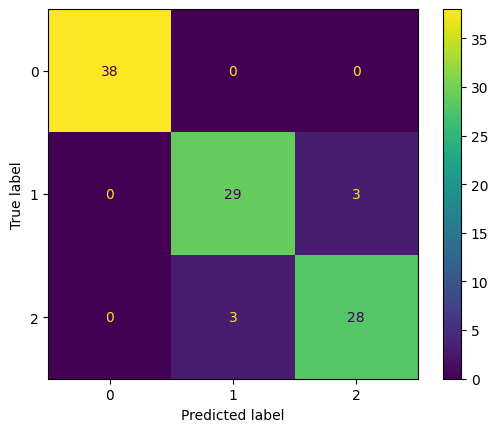

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();


## procedure to pick out model

0. Explore and clean dataset (most important step)
- fill/remove missing values
- remove outliers

1. Do the sklearn steps
- train|test split
- encoding and scaling if needed
- train on train data
- predict on test/val data
- evaluate on test/val data

2. Repeat step 1 for several models

3. Pick the model that scored the best for your particular dataset

4. Use the best model and train on ALL data (both train and test data(X and y))

5. Export this trained model with joblib
    - model is trained and tuned on weights, the model now uses these weights to predict values

In [12]:
# Step 4 - use best model and train on full dataset

model.fit(X,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Step 5 - Export model with joblib
import joblib

joblib.dump(model, "models/iris_classifier.joblib")

['models/iris_classifier.joblib']